# Train LightGB

### Imports

In [107]:
import pandas as pd
import numpy as np
from datetime import date
from pathlib import Path
import os
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns

from utils import TqdmCallback

### Global variables

In [108]:
root = Path(os.getcwd()).parent.parent
DATA_PATH = os.path.join(root, "data")
DATASET_PATH = os.path.join(DATA_PATH, "main_PHMR.csv")
# DATASET_PATH = os.path.join(DATA_PATH, "main_preprocessed.csv")

TARGET = "FarmsNbPaxPHMR"

LIMIT_DATE_TRAIN = pd.Timestamp("2025-12-31")
LIMIT_DATE_VALID = pd.Timestamp("2026-01-30")


### Load and prepare data

In [109]:
df = pd.read_csv(DATASET_PATH)
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])

# df.to_csv("main_preprocessed.csv", index=False)

train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")


X_train = train_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_train = train_df[TARGET]
X_valid = valid_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_valid = valid_df[TARGET]

for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')


Train set: 286758 rows / From 2023-01-01 00:05:00 to 2025-12-30 23:55:00
Valid set: 7348 rows / From 2025-12-31 00:20:00 to 2026-01-29 23:45:00


### Training model

In [110]:
n_estimators = 10000

model = lgb.LGBMRegressor(
    objective="poisson",      
    n_estimators=n_estimators,      
    learning_rate=0.01,
    num_leaves=255,               
    min_child_samples=5,
    feature_fraction=0.8,
    random_state=42,
    verbose=-1
)

tqdm_callback = TqdmCallback(total=n_estimators)
try:
    weights = y_train.apply(lambda x: 5.0 if x > 6 else 1.0) 
    model.fit(
        X_train, y_train,         
        eval_set=[(X_valid, y_valid)], 
        eval_metric="mae",
        sample_weight=weights,
        callbacks=[
            lgb.early_stopping(100),
            tqdm_callback 
        ]
    )
finally:
    tqdm_callback.pbar.close() 

Entraînement LightGBM:   0%|          | 6/10000 [00:00<28:32,  5.84it/s, mae=1.4666]  

Training until validation scores don't improve for 100 rounds


Entraînement LightGBM:  14%|█▍        | 1395/10000 [01:10<08:43, 16.42it/s, mae=0.2813]

Early stopping, best iteration is:
[1295]	valid_0's l1: 0.281978	valid_0's poisson: -0.175599


Entraînement LightGBM:  14%|█▍        | 1395/10000 [01:15<07:43, 18.58it/s, mae=0.2813]


### Prediction and Evaluation

In [111]:
joblib.dump(model, 'lgbm_regressor_PHMR.pkl')

predictions = model.predict(X_valid)
predictions = np.maximum(0, predictions)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── RÉSULTATS FINAUX ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── RÉSULTATS FINAUX ──
   MAE : 0.28 passengers
   R²  : 0.7394
   RMSE : 0.94


### Analysis

#### 1. Feature importance

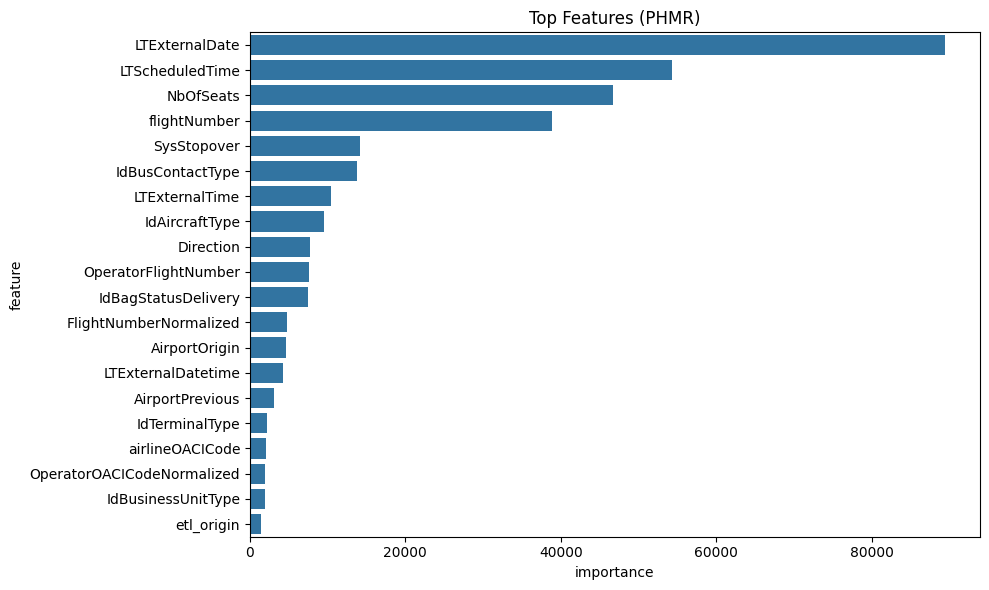

In [112]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv("features_importances_PHMR.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (PHMR)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

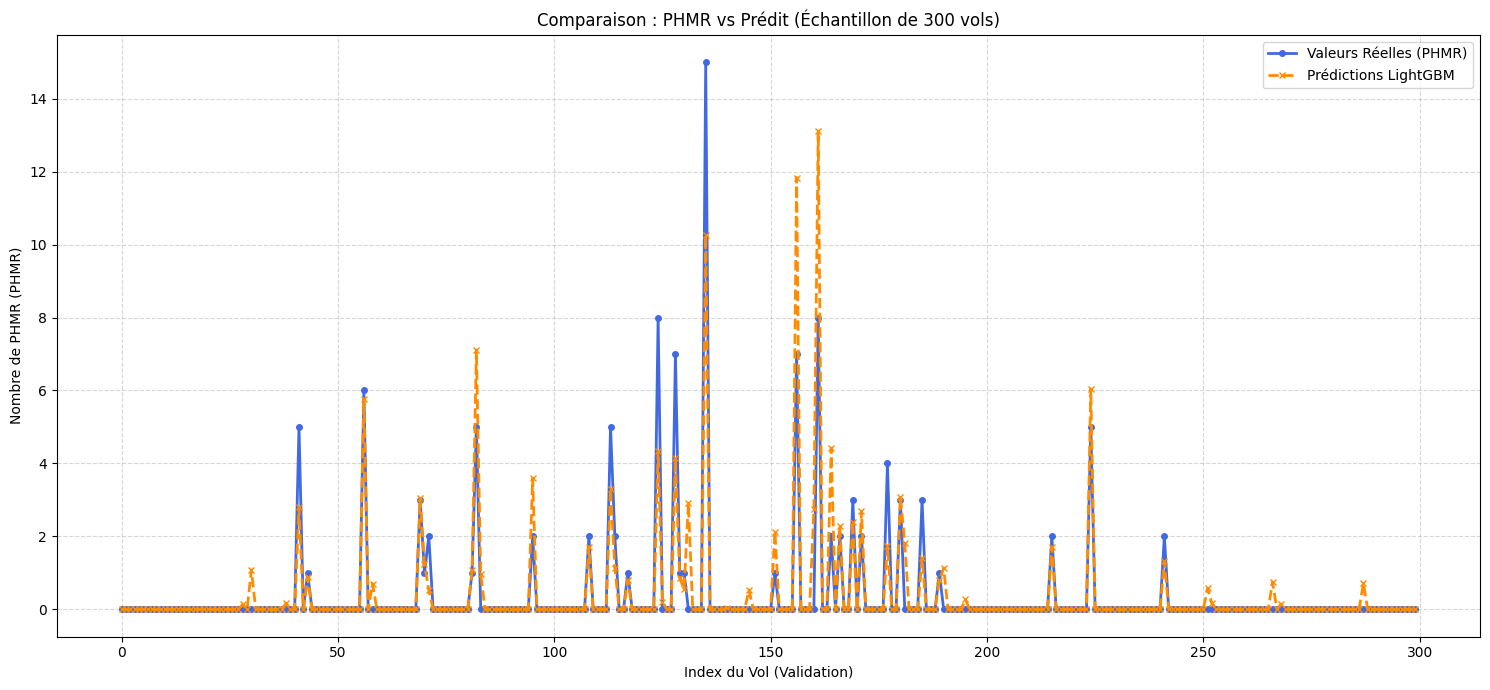

In [113]:
n_sample = 300
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Valeurs Réelles (PHMR)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Prédictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparaison : PHMR vs Prédit (Échantillon de {n_sample} vols)')
plt.ylabel('Nombre de PHMR (PHMR)')
plt.xlabel('Index du Vol (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [ ]:
analysis_df = valid_df.copy()
analysis_df['Predicted_PHMR'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET] - analysis_df['Predicted_PHMR'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET, 
               "Predicted_PHMR", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_PHMR'] = display_df['Predicted_PHMR'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,FarmsNbPaxPHMR,Predicted_NbPax,NbOfSeats,Abs_Error
75138,DAH01081,2026-01-11 17:55:00,24.000000,9.000000,148.000000,15.000000
72920,DAH01099,2026-01-21 11:15:00,25.000000,12.800000,148.000000,12.200000
77464,DAH01081,2026-01-03 11:15:00,2.000000,13.600000,148.000000,11.600000
72197,DAH01039,2026-01-24 11:45:00,18.000000,8.100000,148.000000,9.900000
76192,DAH01037,2026-01-07 12:35:00,19.000000,9.100000,180.000000,9.900000
71902,DAH01461,2026-01-25 17:10:00,18.000000,8.900000,144.000000,9.100000
77419,DAH01037,2026-01-03 12:35:00,0.000000,9.100000,180.000000,9.100000
72704,DAH01155,2026-01-22 11:45:00,2.000000,11.000000,148.000000,9.000000
73721,DAH01461,2026-01-17 17:25:00,4.000000,12.500000,148.000000,8.500000
75444,TVF07312,2026-01-10 12:40:00,13.000000,4.800000,189.000000,8.200000
